In [9]:
!pip install kaggle

In [10]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mwaseemj97","key":"21310016bf34370ee320251030ed2824"}'}

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets download -d meetpatelp27/image-waste-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/meetpatelp27/image-waste-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 213M/213M [00:02<00:00, 88.1MB/s]



In [13]:
!unzip -q image-waste-classification-dataset.zip -d dataset

In [14]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/waste_dataset
dataset/waste_dataset/recyclable
dataset/waste_dataset/organic


Installing Dependencies

In [15]:
!pip install -q tensorflow scikit-learn seaborn matplotlib

Importing Libraries

In [16]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Defining Dataset Paths

In [17]:
train_dir = "/content/dataset/waste_dataset"
test_dir = "/content/dataset/waste_dataset"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

**Data Augmentation**

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

Creating Data Generators

In [19]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 19764 images belonging to 2 classes.
Found 4941 images belonging to 2 classes.
Found 24705 images belonging to 2 classes.


Viewing Class Mapping

In [20]:
print(train_generator.class_indices)

{'organic': 0, 'recyclable': 1}


Build MobileNetV2 Model

In [21]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,434 (9.87 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compiling Model

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Callbacks

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_waste_model.h5",
    save_best_only=True,
    monitor='val_accuracy'
)

Training the Model

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=45,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8894 - loss: 0.2698

618/618 ━━━━━━━━━━━━━━━━━━━━ 356s 536ms/step - accuracy: 0.9098 - loss: 0.2268 - val_accuracy: 0.9118 - val_loss: 0.2226
Epoch 2/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9340 - loss: 0.1712

618/618 ━━━━━━━━━━━━━━━━━━━━ 300s 485ms/step - accuracy: 0.9330 - loss: 0.1718 - val_accuracy: 0.9194 - val_loss: 0.2060
Epoch 3/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 300s 485ms/step - accuracy: 0.9409 - loss: 0.1517 - val_accuracy: 0.9041 - val_loss: 0.2428
Epoch 4/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 299s 483ms/step - accuracy: 0.9433 - loss: 0.1482 - val_accuracy: 0.8812 - val_loss: 0.2747
Epoch 5/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 298s 482ms/step - accuracy: 0.9497 - loss: 0.1317 - val_accuracy: 0.9148 - val_loss: 0.2152
Epoch 6/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9469 - loss: 0.1305

618/618 ━━━━━━━━━━━━━━━━━━━━ 300s 486ms/step - accuracy: 0.9484 - loss: 0.1296 - val_accuracy: 0.9253 - val_loss: 0.2004
Epoch 7/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 305s 493ms/step - accuracy: 0.9541 - loss: 0.1185 - val_accuracy: 0.9124 - val_loss: 0.2239
Epoch 8/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 299s 484ms/step - accuracy: 0.9550 - loss: 0.1162 - val_accuracy: 0.9237 - val_loss: 0.2074
Epoch 9/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 295s 477ms/step - accuracy: 0.9580 - loss: 0.1082 - val_accuracy: 0.9016 - val_loss: 0.2629
Epoch 10/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 298s 483ms/step - accuracy: 0.9597 - loss: 0.1040 - val_accuracy: 0.9063 - val_loss: 0.2827
Epoch 11/45
618/618 ━━━━━━━━━━━━━━━━━━━━ 296s 479ms/step - accuracy: 0.9595 - loss: 0.1067 - val_accuracy: 0.9231 - val_loss: 0.2249


Ploting Accuracy

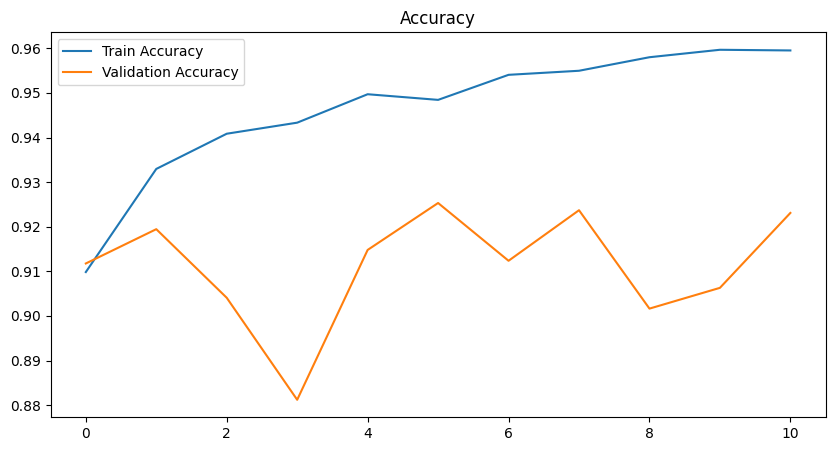

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()
plt.title("Accuracy")
plt.show()

Plotting Loss

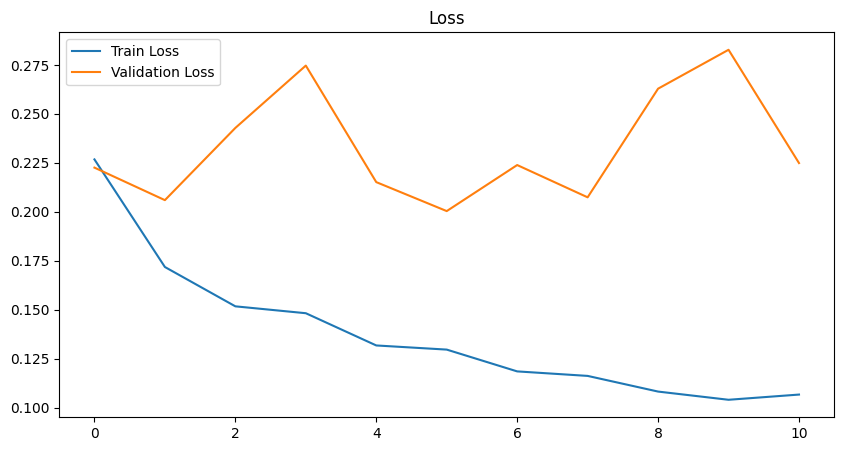

In [26]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()
plt.title("Loss")
plt.show()

Evaluating the Model

In [27]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

773/773 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.9564 - loss: 0.1167
Test Accuracy: 0.9564460515975952


Predictions

In [28]:
pred_probs = model.predict(test_generator)

predictions = np.argmax(
    pred_probs,
    axis=1
)

true_labels = test_generator.classes

773/773 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step


Classification Report

In [29]:
class_names = list(
    test_generator.class_indices.keys()
)

print(
    classification_report(
        true_labels,
        predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     organic       0.96      0.96      0.96     13880
  recyclable       0.95      0.96      0.95     10825

    accuracy                           0.96     24705
   macro avg       0.96      0.96      0.96     24705
weighted avg       0.96      0.96      0.96     24705



Metrics

In [30]:
accuracy = accuracy_score(
    true_labels,
    predictions
)

precision = precision_score(
    true_labels,
    predictions,
    average='weighted'
)

recall = recall_score(
    true_labels,
    predictions,
    average='weighted'
)

f1 = f1_score(
    true_labels,
    predictions,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9564460635498887
Precision: 0.9565226800686382
Recall   : 0.9564460635498887
F1 Score : 0.956467869301712


Confusion Matrix

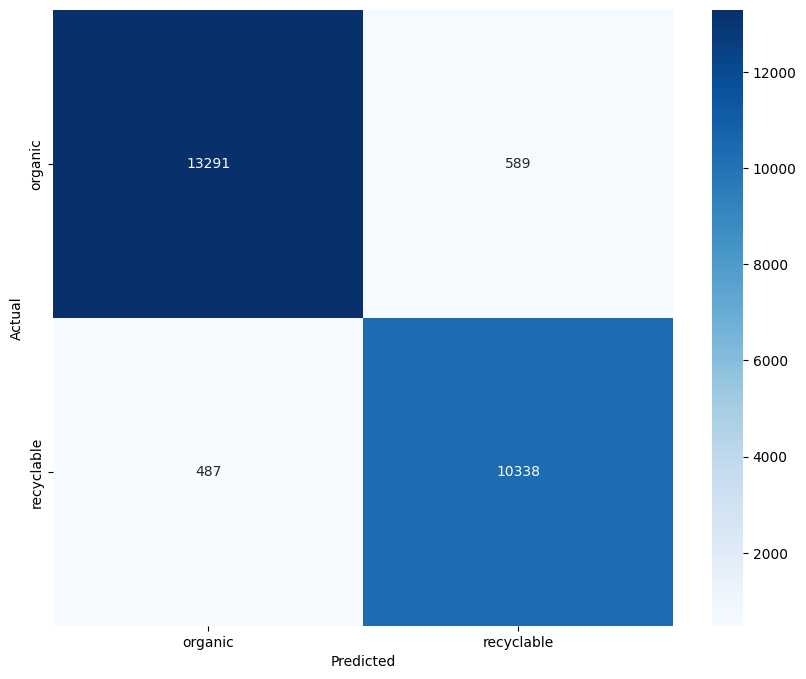

In [31]:
cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Saving the Model

In [32]:
model.save(
    "waste_classifier.h5"
)

print("Model Saved")

Model Saved


Custom Image Prediction

In [34]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

In [35]:
uploaded = files.upload()

Saving organic_000003_photo.jpg to organic_000003_photo.jpg


In [36]:
for img_name in uploaded.keys():

    img_path = img_name

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print("\n========================")
    print("Uploaded Image:", img_name)
    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")
    print("========================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Uploaded Image: organic_000003_photo.jpg
Prediction: organic
Confidence: 81.61%
